<a href="https://colab.research.google.com/github/Grodriguezca/TFG-INF/blob/main/TFGinformatica.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

LIBRERIAS


In [71]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix


AHORA IMPORTAMOS NUESTRO DATASET PARA LA PREDICCION DE ENFERMEDADES CARDIOVASCULARES


In [53]:
df = pd.read_csv("cardiovascular_risk_dataset.csv")

df.head()

,Patient_ID,age,bmi,systolic_bp,diastolic_bp,cholesterol_mg_dl,resting_heart_rate,smoking_status,daily_steps,stress_level,physical_activity_hours_per_week,sleep_hours,family_history_heart_disease,diet_quality_score,alcohol_units_per_week,heart_disease_risk_score,risk_category
0,1,62,25.0,142,93,247,72,Never,11565,3,5.6,8.2,No,7,0.7,28.1,Medium
1,2,54,29.7,158,101,254,74,Current,4036,8,0.5,6.7,No,5,4.5,63.0,High
2,3,46,36.2,170,113,276,80,Current,3043,9,0.4,4.0,No,1,20.8,73.1,High
3,4,48,30.4,153,98,230,73,Former,5604,5,0.6,8.0,No,4,8.5,39.5,Medium
4,5,46,25.3,139,87,206,69,Current,7464,1,2.0,6.1,No,5,3.6,29.3,Medium


INFORMACIÓN DEL DATASET

In [54]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5500 entries, 0 to 5499
Data columns (total 17 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   Patient_ID                        5500 non-null   int64  
 1   age                               5500 non-null   int64  
 2   bmi                               5500 non-null   float64
 3   systolic_bp                       5500 non-null   int64  
 4   diastolic_bp                      5500 non-null   int64  
 5   cholesterol_mg_dl                 5500 non-null   int64  
 6   resting_heart_rate                5500 non-null   int64  
 7   smoking_status                    5500 non-null   object 
 8   daily_steps                       5500 non-null   int64  
 9   stress_level                      5500 non-null   int64  
 10  physical_activity_hours_per_week  5500 non-null   float64
 11  sleep_hours                       5500 non-null   float64
 12  family

ESTADISTICAS BASICAS DE MI DATASET

In [55]:
df.describe()

,Patient_ID,age,bmi,systolic_bp,diastolic_bp,cholesterol_mg_dl,resting_heart_rate,daily_steps,stress_level,physical_activity_hours_per_week,sleep_hours,diet_quality_score,alcohol_units_per_week,heart_disease_risk_score
count,5500.000000,5500.000000,5500.000000,5500.000000,5500.000000,5500.000000,5500.000000,5500.000000,5500.000000,5500.000000,5500.000000,5500.000000,5500.000000,5500.000000
mean,2750.500000,53.872000,28.170818,147.248182,95.756727,239.684182,74.075091,5902.929455,4.907091,3.299364,6.869364,5.162909,3.782200,37.540455
std,1587.857571,21.196017,4.189877,13.222701,9.451559,28.570177,6.392166,3041.084590,2.298173,2.672457,1.091263,2.286134,3.515594,24.287026
min,1.000000,18.000000,15.000000,108.000000,64.000000,147.000000,48.000000,500.000000,1.000000,0.000000,4.000000,1.000000,0.000000,0.000000
25%,1375.750000,36.000000,25.200000,138.000000,89.000000,220.000000,70.000000,3428.000000,3.000000,1.200000,6.200000,3.000000,1.200000,18.400000
50%,2750.500000,54.000000,28.400000,147.000000,96.000000,240.000000,74.000000,5460.000000,5.000000,2.600000,6.900000,5.000000,2.800000,36.700000
75%,4125.250000,72.000000,31.100000,156.000000,102.000000,260.000000,79.000000,7772.000000,7.000000,4.900000,7.600000,7.000000,5.300000,55.500000
max,5500.000000,90.000000,40.900000,192.000000,120.000000,331.000000,92.000000,16793.000000,10.000000,12.900000,10.000000,10.000000,29.200000,100.000000


DISTRIBUCIÓN DE MI DATASET

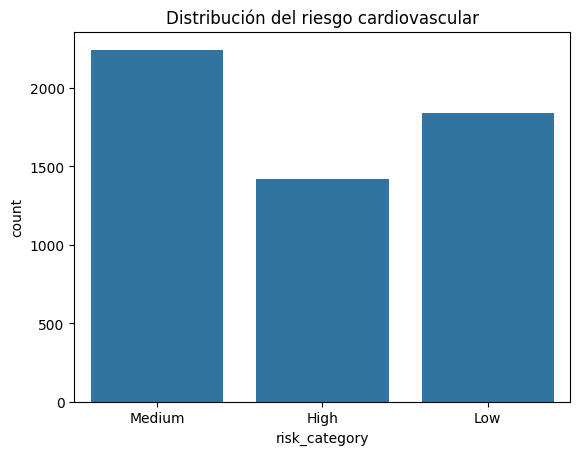

In [56]:
sns.countplot(x="risk_category", data=df)
plt.title("Distribución del riesgo cardiovascular")
plt.show()

**EDA (Aalisis exploratio datos)**


En esta sección se realiza un análisis exploratorio del dataset con el objetivo de comprender la estructura de los datos, las variables disponibles y su distribución. Este análisis permitirá identificar posibles patrones, valores atípicos y relaciones entre variables antes de aplicar modelos de aprendizaje automático.

In [57]:
df.columns

Index(['Patient_ID', 'age', 'bmi', 'systolic_bp', 'diastolic_bp',
       'cholesterol_mg_dl', 'resting_heart_rate', 'smoking_status',
       'daily_steps', 'stress_level', 'physical_activity_hours_per_week',
       'sleep_hours', 'family_history_heart_disease', 'diet_quality_score',
       'alcohol_units_per_week', 'heart_disease_risk_score', 'risk_category'],
      dtype='object')

In [58]:
df.dtypes

,0
Patient_ID,int64
age,int64
bmi,float64
systolic_bp,int64
diastolic_bp,int64
cholesterol_mg_dl,int64
resting_heart_rate,int64
smoking_status,object
daily_steps,int64
stress_level,int64


In [59]:
df.shape

(5500, 17)

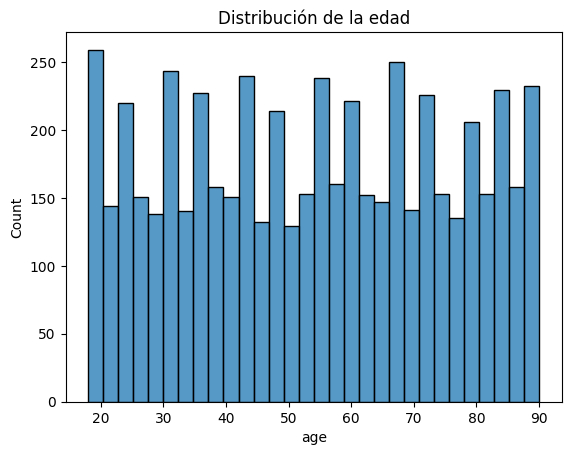

In [60]:
sns.histplot(df["age"], bins=30)
plt.title("Distribución de la edad")
plt.show()

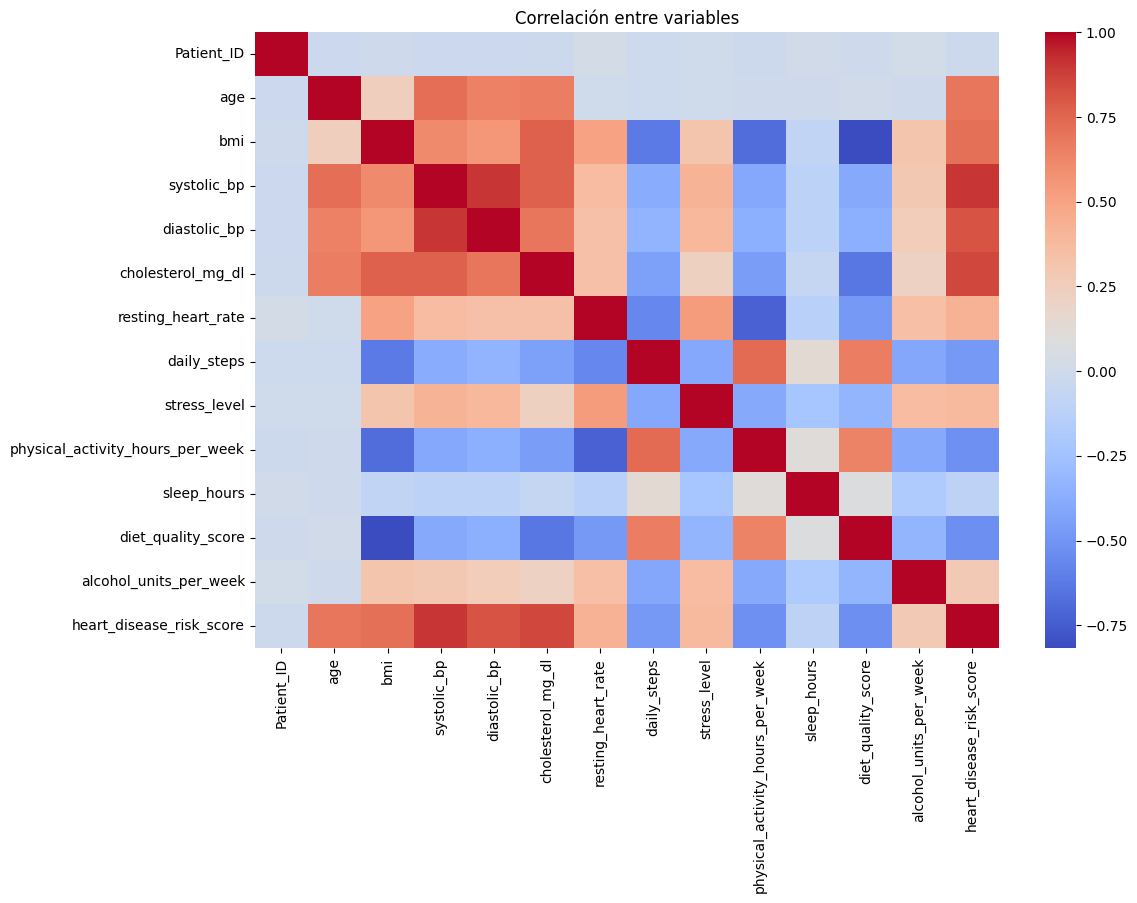

In [61]:
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(numeric_only=True), cmap="coolwarm")
plt.title("Correlación entre variables")
plt.show()

**PREPROCESADO**

Eliminamos variables que son irrelevantes


In [62]:
df = df.drop("Patient_ID", axis=1)

In [63]:
df.columns

Index(['age', 'bmi', 'systolic_bp', 'diastolic_bp', 'cholesterol_mg_dl',
       'resting_heart_rate', 'smoking_status', 'daily_steps', 'stress_level',
       'physical_activity_hours_per_week', 'sleep_hours',
       'family_history_heart_disease', 'diet_quality_score',
       'alcohol_units_per_week', 'heart_disease_risk_score', 'risk_category'],
      dtype='object')

Revisar valores nulos

In [64]:
df.isnull().sum()

,0
age,0
bmi,0
systolic_bp,0
diastolic_bp,0
cholesterol_mg_dl,0
resting_heart_rate,0
smoking_status,0
daily_steps,0
stress_level,0
physical_activity_hours_per_week,0


Vemos que no hay valores nulos y pasamos a convertir las variables categoricas

In [65]:
df["smoking_status"] = df["smoking_status"].map({
    "Non-smoker":0,
    "Former":1,
    "Current":2
})

In [66]:
df["family_history_heart_disease"] = df["family_history_heart_disease"].map({
    "No":0,
    "Yes":1
})

In [51]:
df["risk_category"] = df["risk_category"].map({
    "Low":0,
    "Medium":1,
    "High":2
})

**DIVISION DATSET**

Como mi dataset no viende dividido en train y test hago la division t elimino la variable a predecir

In [83]:
X = df.drop("risk_category", axis=1)
y = df["risk_category"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [68]:
print("Train:", X_train.shape)
print("Test:", X_test.shape)

Train: (4400, 15)
Test: (1100, 15)


Escalamos variables

In [84]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

**BASELINE CON REGRESIÓN LOGISTICA**

In [78]:
df.isnull().sum()

,0
age,0
bmi,0
systolic_bp,0
diastolic_bp,0
cholesterol_mg_dl,0
resting_heart_rate,0
smoking_status,0
daily_steps,0
stress_level,0
physical_activity_hours_per_week,0


In [79]:
df = df.dropna()

In [86]:
model_lr = LogisticRegression(max_iter=5000)

model_lr.fit(X_train, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression(max_iter=5000)

In [87]:
y_pred_lr = model_lr.predict(X_test)


In [88]:
accuracy_score(y_test, y_pred_lr)

0.9893333333333333

In [89]:
print(classification_report(y_test, y_pred_lr))

              precision    recall  f1-score   support

        High       1.00      0.99      1.00       160
         Low       1.00      0.94      0.97        52
      Medium       0.98      1.00      0.99       163

    accuracy                           0.99       375
   macro avg       0.99      0.98      0.99       375
weighted avg       0.99      0.99      0.99       375



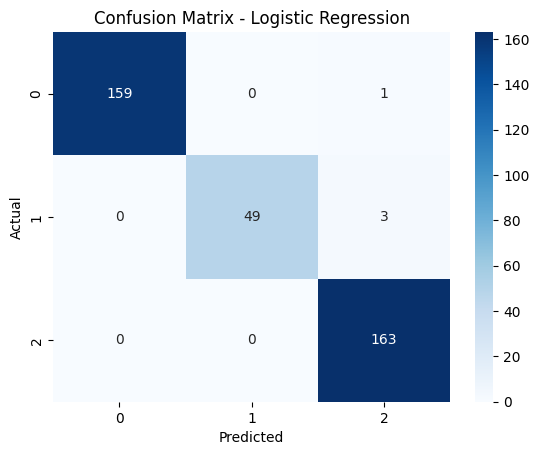

In [90]:
cm = confusion_matrix(y_test, y_pred_lr)

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Logistic Regression")
plt.show()